In [1]:
import pandas as pd
import numpy as np
import ast

In [2]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

movies = movies.merge(credits, on='title')

In [3]:
movies = movies[['title','overview','genres','keywords']]
movies.dropna(inplace=True)

In [4]:
def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return " ".join(L)

movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

In [5]:
movies['tags'] = movies['overview'] + " " + movies['genres'] + " " + movies['keywords']
movies['tags'] = movies['tags'].str.lower()

In [6]:
from collections import Counter

def text_to_vector(text):
    words = text.split()
    return Counter(words)

vectors = movies['tags'].apply(text_to_vector)

In [7]:
def similarity(v1, v2):
    common = set(v1.keys()) & set(v2.keys())
    score = 0
    
    for word in common:
        score += min(v1[word], v2[word])
    
    return score

In [23]:
def recommend(movie_name):
    movie_index = movies[movies['title'] == movie_name].index[0]
    selected_vector = vectors.iloc[movie_index]

    scores = []

    for i in range(len(vectors)):
        score = similarity(selected_vector, vectors.iloc[i])
        scores.append((i, score))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]

    print("Recommended Movies:\n")
    for i in scores:
        print(movies.iloc[i[0]].title)

    # ✅ Graph here
    import matplotlib.pyplot as plt
    values = [s[1] for s in scores]

    plt.figure()
    plt.bar(range(len(values)), values)
    plt.title("Similarity Scores")
    plt.show()

Recommended Movies:

Harry Potter and the Order of the Phoenix
Harry Potter and the Goblet of Fire
Harry Potter and the Philosopher's Stone
The Amazing Spider-Man 2
Harry Potter and the Prisoner of Azkaban


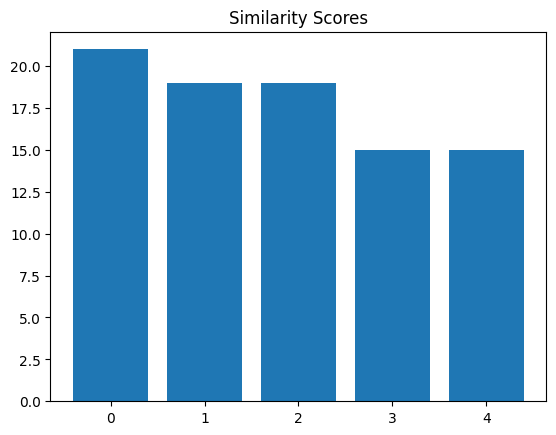

In [28]:
recommend('Harry Potter and the Half-Blood Prince')

Recommended Movies:

Blade: Trinity
The Twilight Saga: Eclipse
Maleficent
The Matrix Reloaded
Bill & Ted's Bogus Journey


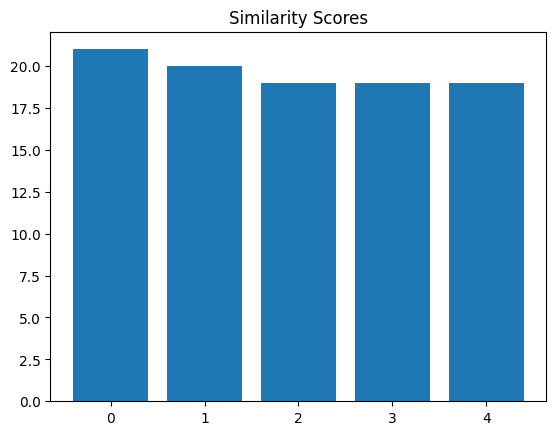

In [30]:
recommend('The Twilight Saga: Breaking Dawn - Part 2')

In [31]:
import pickle

pickle.dump(movies, open('movies.pkl', 'wb'))
pickle.dump(vectors, open('vectors.pkl', 'wb'))